In [1]:
from datasets import load_dataset
from transformers import PreTrainedTokenizerFast
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from pathlib import Path
import math
import logging
from datetime import datetime
from torchvision import datasets, transforms
import torchmetrics
run_time = datetime.now().strftime('%Y%m%d_%H%M%S')
base_dir = Path(run_time)
log_dir  = base_dir / "logs"
save_dir = base_dir / "checkpoints"

log_dir.mkdir(parents=True, exist_ok=True)
save_dir.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(message)s",
    handlers=[
        logging.FileHandler(log_dir / "train.log"),
        logging.StreamHandler()
    ],
    force=True
)

logger = logging.getLogger(__name__)


f:\repo\VIT-Pytorch-Implementation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.Imagenette(root='./data_imagenette', split='train', size='full', download=True, transform=transform_train)
val_dataset = datasets.Imagenette(root='./data_imagenette', split='val', size='full', download=True, transform=transform_val)
print(f"학습 데이터 개수: {len(train_dataset)}장")
print(f"검증 데이터 개수: {len(val_dataset)}장")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

학습 데이터 개수: 9469장
검증 데이터 개수: 3925장


7653 번째 이미지 크기 (가로,세로) : (150, 200)


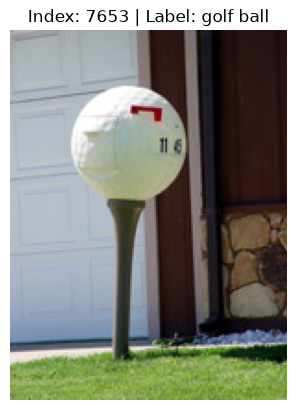

In [3]:
# 이미지 확인하기
import matplotlib.pyplot as plt
import random

test_dataset = datasets.Imagenette(root='./data_imagenette', split='train', size='full', download=True)
random_idx = random.randint(0, len(test_dataset)-1)
image, label = test_dataset[random_idx]
print(f"{random_idx} 번째 이미지 크기 (가로,세로) : {image.size}")
plt.imshow(image)
plt.title(f"Index: {random_idx} | Label: {test_dataset.classes[label][0]}")
plt.axis('off')
plt.show()

In [4]:
# for test
IMG_SIZE   = 224     
PATCH_SIZE = 8       
N_LAYER    = 4        
INPUT_DIM  = 256    
HIDDEN_DIM = 1024   
N_HEADS    = 4 
DROP_P     = 0.1
N_CLASS    = 10
BATCH_SIZE = 64 
EPOCHS     = 5       
LR         = 3e-4

# VIT-BASE 
# IMG_SIZE   = 224
# PATCH_SIZE = 16             
# BATCH_SIZE = 32
# INPUT_DIM  = 768
# HIDDEN_DIM = 3072
# N_HEADS    = 12
# N_LAYER    = 12
# DROP_P     = 0.1
# N_CLASS    = 1000
# EPOCHS     = 10
# LR         = 3e-4

In [5]:
class MHAttention(nn.Module):
    def __init__(self, n_dim, n_heads):
        super().__init__()

        self.n_heads = n_heads
        self.d_k = torch.tensor((n_dim / n_heads) ** 0.5)

        self.fc_q = nn.Linear(n_dim, n_dim)
        self.fc_k = nn.Linear(n_dim, n_dim)
        self.fc_v = nn.Linear(n_dim, n_dim)
        self.fc_o = nn.Linear(n_dim, n_dim)


    def forward(self, x):
        Q = self.fc_q(x)
        K = self.fc_k(x)
        V = self.fc_v(x)

        Q = Q.view(x.shape[0], x.shape[1], self.n_heads, x.shape[2] // self.n_heads).transpose(1, 2)
        K = K.view(x.shape[0], x.shape[1], self.n_heads, x.shape[2] // self.n_heads).transpose(1, 2)
        V = V.view(x.shape[0], x.shape[1], self.n_heads, x.shape[2] // self.n_heads).transpose(1, 2)

        attention = Q @ K.transpose(-1, -2) / self.d_k

        attention = torch.softmax(attention, dim=-1)
        attention = attention @ V

        out = attention.transpose(1, 2).contiguous()
        out = out.view(*x.shape)
        out = self.fc_o(out)
        return out

class FFN(nn.Module):
    def __init__(self, input_dim, hidden_dim, drop_p):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, input_dim)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(drop_p)
        
    def forward(self, x):
        return self.dropout(self.fc2(self.gelu(self.fc1(x))))

class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_heads, drop_p):
        super().__init__()

        self.MHA = MHAttention(input_dim, n_heads)
        self.FFN = FFN(input_dim, hidden_dim, drop_p)
        self.LN1 = nn.LayerNorm(input_dim)
        self.LN2 = nn.LayerNorm(input_dim)

    def forward(self, x):

        x = x + self.MHA(self.LN1(x))
        x = x + self.FFN(self.LN2(x))
        return x

class VIT(nn.Module):
    def __init__(self, img_size, patch_size, n_layer, input_dim, hidden_dim, n_heads, drop_p, n_class, representation_size=None):
        super().__init__()

        self.n_layer = n_layer
        patch_num = (img_size // patch_size) ** 2 # patch_size 비율 맞다고 가정 (resize로 조절함)
        self.pos_embedding = nn.Parameter(0.02*torch.randn(patch_num+1, input_dim)) # cls_token 1추가
        self.input_embedding = nn.Conv2d(3, input_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(input_dim))

        self.dropout = nn.Dropout(drop_p)

        self.layers = nn.ModuleList([Encoder(input_dim, hidden_dim, n_heads, drop_p) for _ in range(n_layer)])

        self.LN = nn.LayerNorm(input_dim)

        if representation_size is None: # fine-tuning
            self.head = nn.Linear(input_dim, n_class)
        else: # pre-training
            self.head = nn.Sequential(
                nn.Linear(input_dim, representation_size),
                nn.Tanh(),
                nn.Linear(representation_size, n_class)
            )


        self.apply(self._init_weights)

        for name, m in self.named_modules():
            if name.endswith(('fc_o', 'fc2')):
                nn.init.normal_(m.weight, mean=0.0, std=0.02 / (2 * self.n_layer) ** 0.5)

        # conv의 patch 개수가 많아지면 분산이 커지는것 방지
        fan_in = 3 * (patch_size ** 2) 
        nn.init.trunc_normal_(self.input_embedding.weight, std=math.sqrt(1 / fan_in))

        if representation_size is None: # fine-tuning
            nn.init.zeros_(self.head.weight)
        else: # pre-training
            nn.init.zeros_(self.head[2].weight)

    def forward(self, x):

        x = self.input_embedding(x).flatten(2).transpose(1, 2) # 개 채 행 열 -> 개 채 차 -> 개 패 차
        x = torch.concat([self.cls_token.expand(x.shape[0], 1, -1), x], dim=1) # 개 (cls+패) 차
        x = x + self.pos_embedding.expand_as(x)
        x = self.dropout(x)

        for layer in self.layers:
            x = layer(x)
        
        x = self.LN(x)
        out = self.head(x[:, 0])
        return out

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.trunc_normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        




In [6]:
def train_one_epoch(model, loader, optimizer, criterion, epoch, epochs, device):
    model.train()

    train_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Train [{epoch+1}/{epochs}]", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = torch.argmax(logits, dim=1)
        correct += (pred == y).sum().item()
        total  += y.size(0)

    return train_loss / len(loader), correct / total

@torch.no_grad()
def validate(model, loader, criterion, epoch, epochs, device, precision_metric=None, recall_metric=None, f1_metric=None):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Valid [{epoch+1}/{epochs}]", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        val_loss += loss.item()

        pred = torch.argmax(logits, dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

        if precision_metric is not None:
            precision_metric.update(pred, y)
            recall_metric.update(pred, y)
            f1_metric.update(pred, y)

    return val_loss / len(loader), correct / total


In [7]:
def train(model, train_loader, val_loader, optimizer, criterion, epochs, device, num_classes, save_dir="checkpoints"):
    best_val_loss = float('inf')
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    precision_metric = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average="macro").to(device)
    recall_metric = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average="macro").to(device)
    f1_metric = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average="macro").to(device)

    train_history = {"loss": [], "acc": []}
    val_history = {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []}

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, epoch, epochs, device)
        val_loss, val_acc = validate(
            model, val_loader, criterion, epoch, epochs, device,
            precision_metric, recall_metric, f1_metric
        )

        val_precision = precision_metric.compute().item()
        val_recall = recall_metric.compute().item()
        val_f1 = f1_metric.compute().item()
        precision_metric.reset()
        recall_metric.reset()
        f1_metric.reset()

        train_history['loss'].append(train_loss)
        train_history['acc'].append(train_acc)
        val_history['loss'].append(val_loss)
        val_history['acc'].append(val_acc)
        val_history['precision'].append(val_precision)
        val_history['recall'].append(val_recall)
        val_history['f1'].append(val_f1)

        logger.info(
            f"Epoch {epoch+1}/{epochs} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} "
            f"| val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} "
            f"| val_precision: {val_precision:.4f} | val_recall: {val_recall:.4f} | val_f1: {val_f1:.4f}"
        )

        ckpt = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1,
        }

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(ckpt, save_dir / "best_model.pt")

        torch.save(ckpt, save_dir / f"ckpt_epoch{epoch+1}.pt")

    return train_history, val_history

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

assert IMG_SIZE % PATCH_SIZE == 0, "img_size는 patch_size로 나누어떨어져야 함"

model = VIT(
    img_size   = IMG_SIZE,
    patch_size = PATCH_SIZE,
    n_layer    = N_LAYER,
    input_dim  = INPUT_DIM,
    hidden_dim = HIDDEN_DIM,
    n_heads    = N_HEADS,
    drop_p     = DROP_P,
    n_class    = N_CLASS,
    representation_size = None,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

parameters: 3,412,746


In [9]:
print(device)

cuda


In [ ]:
train_history, val_history = train(model, train_loader, val_loader, optimizer, criterion, epochs=5, device=device, num_classes=N_CLASS,save_dir=save_dir)

2026-07-12 22:46:20,362 | Epoch 1/5 | train_loss: 2.0817 | train_acc: 0.2550 | val_loss: 1.9890 | val_acc: 0.2940 | val_precision: 0.3018 | val_recall: 0.2981 | val_f1: 0.2327
2026-07-12 22:49:29,844 | Epoch 2/5 | train_loss: 1.8764 | train_acc: 0.3383 | val_loss: 1.8919 | val_acc: 0.3307 | val_precision: 0.3373 | val_recall: 0.3347 | val_f1: 0.2959
2026-07-12 22:52:40,893 | Epoch 3/5 | train_loss: 1.6968 | train_acc: 0.4116 | val_loss: 1.5864 | val_acc: 0.4469 | val_precision: 0.4765 | val_recall: 0.4503 | val_f1: 0.4276
2026-07-12 22:55:55,994 | Epoch 4/5 | train_loss: 1.4668 | train_acc: 0.5072 | val_loss: 1.4289 | val_acc: 0.5152 | val_precision: 0.5462 | val_recall: 0.5139 | val_f1: 0.5033
2026-07-12 22:59:17,658 | Epoch 5/5 | train_loss: 1.3231 | train_acc: 0.5554 | val_loss: 1.3528 | val_acc: 0.5564 | val_precision: 0.5768 | val_recall: 0.5596 | val_f1: 0.5505


({'loss': [2.0817352919965177,
   1.8763539315880955,
   1.6968416764929488,
   1.466834087629576,
   1.3230523926180762],
  'acc': [0.2550427711479565,
   0.33826169606083006,
   0.4115534903368888,
   0.507234132432147,
   0.5553912767979723]},
 {'loss': [1.9889726427293593,
   1.8918800911595743,
   1.586380939329824,
   1.4288592367402968,
   1.3527596294879913],
  'acc': [0.2940127388535032,
   0.33070063694267515,
   0.44687898089171973,
   0.5151592356687898,
   0.5564331210191082],
  'precision': [0.30181023478507996,
   0.33731991052627563,
   0.47645774483680725,
   0.5461581349372864,
   0.5768093466758728],
  'recall': [0.298096239566803,
   0.33467304706573486,
   0.4503192901611328,
   0.5138813257217407,
   0.5596158504486084],
  'f1': [0.2327452003955841,
   0.2958654761314392,
   0.42755892872810364,
   0.5032569169998169,
   0.5504547357559204]})

In [12]:
plt.plot(train_history['loss'])
plt.plot(val_history['loss'])
plt.title('Loss History')
plt.legend(['TRAIN', 'VAL'])
plt.plot()

NameError: name 'train_history' is not defined

In [30]:
import shutil
from pathlib import Path

shutil.copytree("/content/20260628_115533", "/content/drive/MyDrive/GPT-result/20260628_115533")

'/content/drive/MyDrive/GPT-result/20260628_115533'

In [31]:
from google.colab import runtime
runtime.unassign()

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
import os
print(os.listdir("/content"))

['.config', '20260628_110526', '20260628_115438', '20260628_115533', '20260628_105455', '20260628_115303', 'drive', '20260628_110526.zip', 'sample_data']


In [21]:
import shutil
from pathlib import Path

# Drive에 복사
Path("/content/drive/MyDrive/GPT-result").mkdir(parents=True, exist_ok=True)
shutil.copy("/content/20260628_110526/checkpoints/best_model.pt", "/content/drive/MyDrive/GPT-result/best_model.pt")
shutil.copy("/content/20260628_110526/logs/train.log", "/content/drive/MyDrive/GPT-result/train.log")

'/content/drive/MyDrive/GPT-result/train.log'

In [19]:
import os
from pathlib import Path

for f in ["/content/20260628_110526/checkpoints/best_model.pt",
          "/content/20260628_110526/logs/train.log"]:
    size = Path(f).stat().st_size
    print(f"{f}: {size / 1024**2:.1f} MB")

/content/20260628_110526/checkpoints/best_model.pt: 1890.7 MB
/content/20260628_110526/logs/train.log: 0.0 MB


In [21]:
ckpt = torch.load("/content/20260628_115533/checkpoints/best_model.pt", map_location=device)
print(f"epoch: {ckpt['epoch']}")
print(f"val_loss: {ckpt['val_loss']:.4f}")
print(f"perplexity: {math.exp(ckpt['val_loss']):.2f}")

epoch: 4
val_loss: 5.4097
perplexity: 223.58


In [27]:
@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens, device, max_len=MAX_LEN, temperature=0.8):
    input_ids = tokenizer.encode(prompt)
    input_ids = torch.tensor(input_ids).unsqueeze(0).to(device)

    for _ in range(max_new_tokens):
        if input_ids.shape[1] > max_len: break
        logit = model(input_ids)
        logit = logit[:, -1, :] / temperature  # temperature 적용
        probs = torch.softmax(logit, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)  # 확률적 샘플링
        input_ids = torch.cat([input_ids, next_token], dim=1)

    return tokenizer.decode(input_ids[0].tolist())

In [28]:
# model.load_state_dict(ckpt['model_state_dict'])
result = generate(model, tokenizer, "날씨가 참 좋군", max_new_tokens=100, device=device)
print(result)

날씨가 참 좋군지 않은 것을 우려한 것으로 보인다. 윤치연의 도움을 받아 윤치영의 칼날을 마쳤다. 그리고 윤치호의 원고를 맡았던 윤치연의 외 이비인 신병오의 딸 윤치소가 그의 바지 부상을 입혔고 윤치영은 "내 사람은 없다고 생각한다."며 김재규가(金正奇祐, 永浩, ?~1825)의 술자리에 임명되었으나 수락하였다. 그러나 윤치창은 연회 도중 혼수가 났다고 한다.

한국인협회(韓國廻廊) 교수 김영
